In [ ]:
%pip -q install pretty_midi mido tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 83.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Device: cuda
Vocabulary size: 1411
MIDI files found in Drive: 697
MIDI files used: 160


Tokenizing MIDI:   0%|          | 0/128 [00:00<?, ?it/s]

Skipped: 00127_Thank_You_for_the_Music.2.mid data byte must be in range 0..127
Skipped: 00112_Dreadlock_Holiday.4.mid data byte must be in range 0..127


Tokenizing MIDI:   0%|          | 0/32 [00:00<?, ?it/s]

Train MIDI files: 128
Test MIDI files: 32
Train sequences: (2356, 128)
Test sequences: (608, 128)
MusicTransformer(
  (token_embedding): Embedding(1411, 96, padding_idx=0)
  (position_embedding): Embedding(128, 96)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=192, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (output_layer): Linear(in_features=96

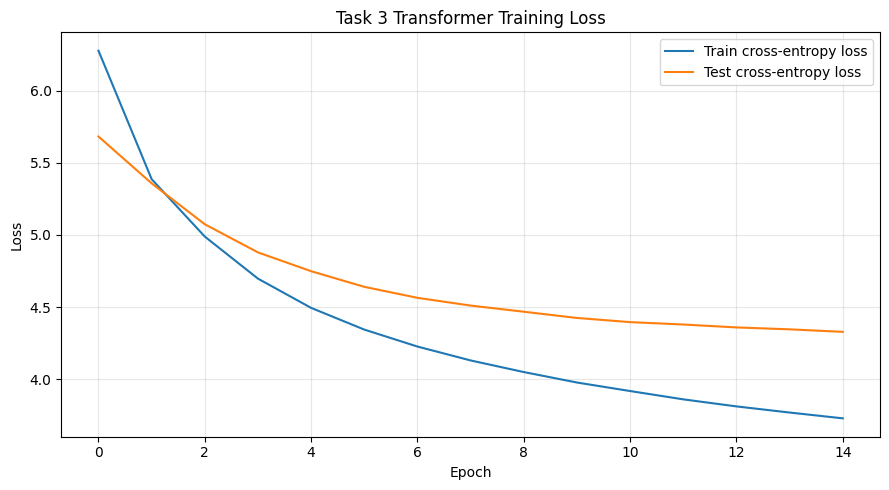

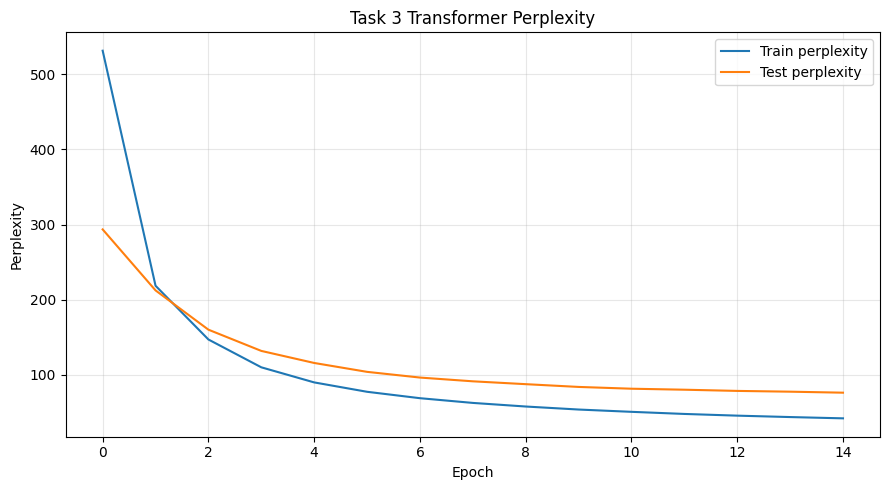

Generated task3_transformer_generated_1.mid | notes: 379 | tokens: 380
Generated task3_transformer_generated_2.mid | notes: 419 | tokens: 420
Generated task3_transformer_generated_3.mid | notes: 339 | tokens: 340
Generated task3_transformer_generated_4.mid | notes: 419 | tokens: 420
Generated task3_transformer_generated_5.mid | notes: 379 | tokens: 380
Generated task3_transformer_generated_6.mid | notes: 419 | tokens: 420
Generated task3_transformer_generated_7.mid | notes: 339 | tokens: 340
Generated task3_transformer_generated_8.mid | notes: 339 | tokens: 340
Generated task3_transformer_generated_9.mid | notes: 339 | tokens: 340
Generated task3_transformer_generated_10.mid | notes: 259 | tokens: 260


,Model,Loss,Perplexity,Pitch Histogram Distance,Rhythm Diversity,Repetition Ratio,Average Note Count
0,Random Token Baseline,5.747487,313.402139,0.095726,0.004878,0.0,328.0
1,Markov Token Baseline,5.757126,316.437533,0.129030,0.004893,0.0,327.0
2,Task 3 Transformer,4.329422,75.900369,0.280020,0.004408,0.0,363.0


,sample,notes,tokens
0,task3_transformer_generated_1.mid,379,380
1,task3_transformer_generated_2.mid,419,420
2,task3_transformer_generated_3.mid,339,340
3,task3_transformer_generated_4.mid,419,420
4,task3_transformer_generated_5.mid,379,380
5,task3_transformer_generated_6.mid,419,420
6,task3_transformer_generated_7.mid,339,340
7,task3_transformer_generated_8.mid,339,340
8,task3_transformer_generated_9.mid,339,340
9,task3_transformer_generated_10.mid,259,260


,Model,Final Train Loss,Final Test Loss,Final Train Perplexity,Final Test Perplexity
0,Task 3 Transformer,3.730553,4.329422,41.702179,75.900369


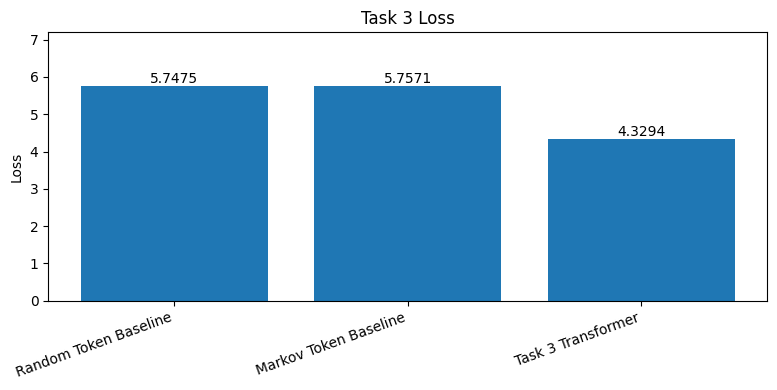

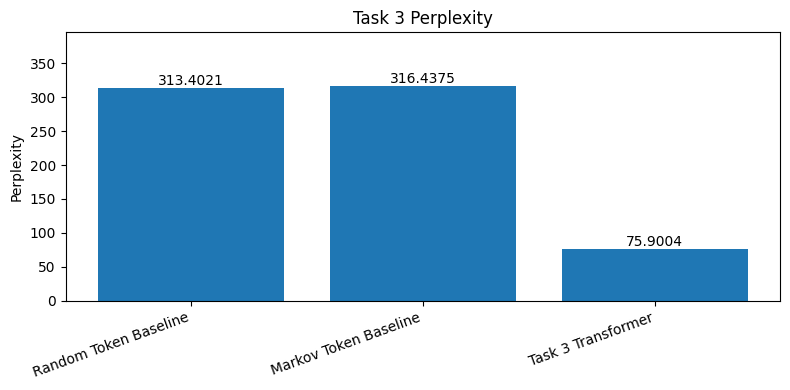

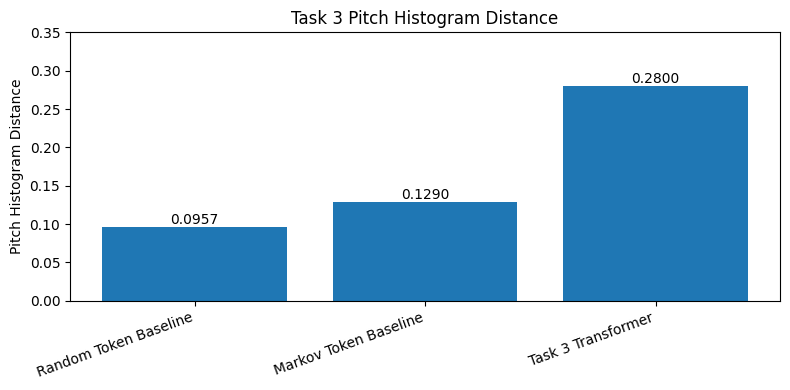

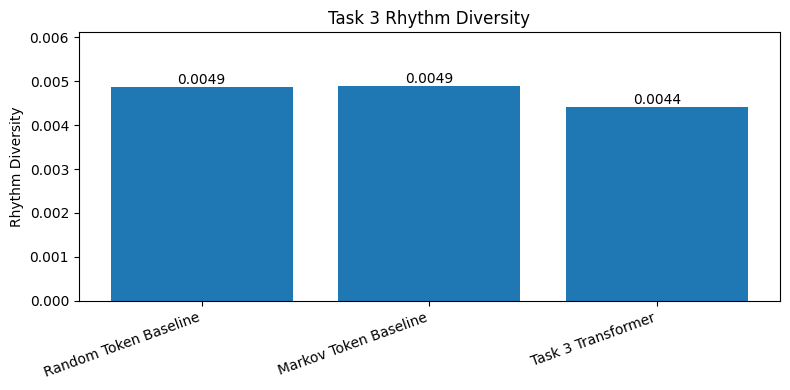

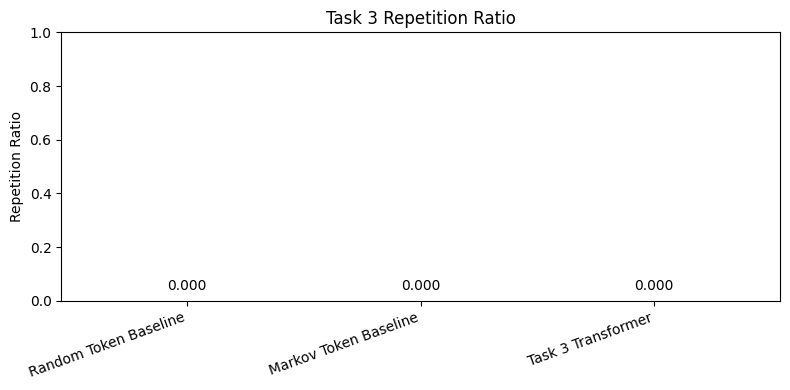

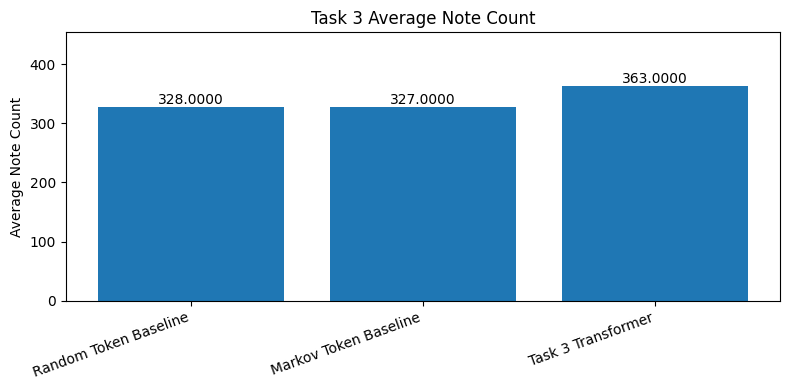

,Task,Dataset,MIDI files used,Train MIDI files,Test MIDI files,Train sequences,Test sequences,Vocabulary size,Sequence length,Final train loss,Final test loss,Final train perplexity,Final test perplexity,Generated MIDI samples
0,Task 3 Transformer-Based Music Generator,Lakh MIDI Clean subset,160,128,32,2356,608,1411,128,3.730553,4.329422,41.702179,75.900369,10


Task 3 finished.
Generated MIDI: /content/CSE425_Task3_Transformer_Music_Generator/outputs/generated_midis
Plots: /content/CSE425_Task3_Transformer_Music_Generator/outputs/plots
Results: /content/CSE425_Task3_Transformer_Music_Generator/outputs/results
ZIP file in Colab: /content/CSE425_Task3_Transformer_Music_Generator.zip
ZIP file copied to Drive: /content/drive/MyDrive/CSE425_Project/task3_outputs/CSE425_Task3_Transformer_Music_Generator.zip


In [ ]:
# Converting MIDI files into symbolic pitch-duration tokens, then training
# a causal Transformer to predict the next token — generating longer sequences than Tasks 1 and 2.

import random
import shutil
import warnings
import math
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi  # handling MIDI file I/O

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

# Fixing all random seeds so results are reproducible across runs
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Selecting GPU if available, otherwise falling back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive_midi_folder = Path("/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre")
project_folder = Path("/content/CSE425_Task3_Transformer_Music_Generator")

# Wiping any previous run so we always start fresh
if project_folder.exists():
    shutil.rmtree(project_folder)

# Defining all output subdirectory paths
raw_folder = project_folder / "data" / "raw_midi"
processed_folder = project_folder / "data" / "processed"
output_folder = project_folder / "outputs"
midi_output_folder = output_folder / "generated_midis"
plot_folder = output_folder / "plots"
result_folder = output_folder / "results"
model_folder = output_folder / "model"

# Creating all folders in one pass
for folder in [raw_folder, processed_folder, midi_output_folder, plot_folder, result_folder, model_folder]:
    folder.mkdir(parents=True, exist_ok=True)

all_midi_files = []

# Searching recursively to handle subfolders inside the multigenre folder
for pattern in ["*.mid", "*.midi", "*.MID", "*.MIDI"]:
    all_midi_files.extend(list(drive_midi_folder.rglob(pattern)))

if len(all_midi_files) == 0:
    raise ValueError("No MIDI files found. Check the Drive folder path.")

random.shuffle(all_midi_files)

lowest_note = 21        # MIDI pitch for the lowest piano key (A0)
note_count = 88         # Total keys on a standard piano
duration_bins = 16      # Number of discrete duration buckets (1 = shortest, 16 = longest)
frame_rate = 8          # Frames per second used when quantizing note durations

# Defining special token IDs — these sit outside the music token range
pad_token = 0           # Padding token for filling short sequences to fixed length
bos_token = 1           # Beginning-of-sequence marker
eos_token = 2           # End-of-sequence marker
special_tokens = 3      # Total count of special tokens (used as offset into the vocabulary)

# Vocabulary covers all (pitch, duration) combinations plus the 3 special tokens
vocab_size = special_tokens + note_count * duration_bins

sequence_length = 128   # Number of tokens per training window
token_stride = 64       # Hop size between windows — 50% overlap
max_midi_files = 160    # Capping file count to keep processing time manageable
max_notes_per_file = 1200   # Truncating very long MIDI files to keep memory usage reasonable
max_train_sequences = 3500  # Total training windows
max_test_sequences = 700    # Total test windows
train_ratio = 0.8           # Splitting 80% for training, 20% for testing

batch_size = 32
epochs = 15
learning_rate = 0.0005
d_model = 96            # Transformer embedding dimension
n_heads = 4             # Number of attention heads (d_model must be divisible by n_heads)
num_layers = 2          # Number of stacked Transformer encoder layers
dim_feedforward = 192   # Inner dimension of the feedforward sublayer (2x d_model)
dropout = 0.1

generated_sample_count = 10     # Number of MIDI files to generate after training
min_generated_tokens = 120      # Minimum music tokens required before accepting a generated sample

# Copying files locally and renaming with a numeric prefix to avoid name collisions
selected_files = all_midi_files[:max_midi_files]

for index, file in enumerate(selected_files):
    clean_name = file.name.replace("/", "_")
    shutil.copy(file, raw_folder / f"{index:05d}_{clean_name}")

# Collecting and sorting copied files for consistent ordering
midi_files = []

for pattern in ["*.mid", "*.midi", "*.MID", "*.MIDI"]:
    midi_files.extend(list(raw_folder.glob(pattern)))

midi_files = sorted(midi_files)

print("Device:", device)
print("Vocabulary size:", vocab_size)
print("MIDI files found in Drive:", len(all_midi_files))
print("MIDI files used:", len(midi_files))

if len(midi_files) < 20:
    raise ValueError("Use at least 20 MIDI files.")


def note_to_token(pitch, duration_step):
    # Encoding a (pitch, duration) pair into a single integer token
    # Layout: special_tokens + pitch_index * duration_bins + duration_index
    pitch_index = int(pitch) - lowest_note
    duration_index = int(np.clip(duration_step, 1, duration_bins)) - 1
    return special_tokens + pitch_index * duration_bins + duration_index


def token_to_note(token):
    # Decoding a token back to (pitch, duration_step) — returning None for special tokens
    token = int(token)

    if token < special_tokens:
        return None

    value = token - special_tokens
    pitch_index = value // duration_bins
    duration_index = value % duration_bins

    pitch = lowest_note + pitch_index
    duration_step = duration_index + 1

    return pitch, duration_step


def midi_to_tokens(path):
    # Converting a MIDI file to a flat list of pitch-duration tokens
    # Sorting notes by start time and skipping drum tracks
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        notes = []

        for instrument in midi.instruments:
            if instrument.is_drum:
                continue  # skipping drums — they don't have pitched notes

            for note in instrument.notes:
                if lowest_note <= note.pitch < lowest_note + note_count:
                    # Quantizing duration to the nearest frame and clamping to duration_bins
                    duration = max(1, int(round((note.end - note.start) * frame_rate)))
                    duration = min(duration, duration_bins)
                    notes.append((note.start, note.pitch, duration))

        if len(notes) == 0:
            return None

        # Sorting by start time then pitch to get a deterministic ordering
        notes = sorted(notes, key=lambda item: (item[0], item[1]))
        notes = notes[:max_notes_per_file]

        tokens = [bos_token]

        for start, pitch, duration in notes:
            tokens.append(note_to_token(pitch, duration))

        tokens.append(eos_token)

        return tokens

    except Exception as error:
        print("Skipped:", path.name, error)
        return None


def build_token_sequences(files, limit):
    # Slicing each file's token list into overlapping fixed-length windows
    # Each window becomes one training example (input = window[:-1], target = window[1:])
    sequences = []

    for file in tqdm(files, desc="Tokenizing MIDI"):
        tokens = midi_to_tokens(file)

        if tokens is None:
            continue

        if len(tokens) < 16:
            continue  # skipping files that are too short to form even one window

        for start in range(0, max(1, len(tokens) - 1), token_stride):
            chunk = tokens[start:start + sequence_length + 1]

            # Padding short chunks at the end of the file to the required length
            if len(chunk) < sequence_length + 1:
                chunk = chunk + [pad_token] * (sequence_length + 1 - len(chunk))

            music_token_count = sum(1 for token in chunk if token >= special_tokens)

            # Dropping windows that contain almost no music tokens
            if music_token_count >= 8:
                sequences.append(chunk)

            if len(sequences) >= limit:
                break

        if len(sequences) >= limit:
            break

    random.shuffle(sequences)

    return np.array(sequences, dtype=np.int64)


# Splitting at the file level to avoid data leakage between train and test
random.shuffle(midi_files)

train_file_count = int(len(midi_files) * train_ratio)
train_files = midi_files[:train_file_count]
test_files = midi_files[train_file_count:]

# Handling the edge case where the test set ends up empty
if len(test_files) == 0:
    test_files = train_files[-1:]
    train_files = train_files[:-1]

train_sequences = build_token_sequences(train_files, max_train_sequences)
test_sequences = build_token_sequences(test_files, max_test_sequences)

if len(train_sequences) == 0 or len(test_sequences) == 0:
    raise ValueError("No valid token sequences were created.")

# Shifting by one position: input = tokens[0:-1], target = tokens[1:]
# This way each input token is paired with the next token it should predict
train_inputs = train_sequences[:, :-1]
train_targets = train_sequences[:, 1:]

test_inputs = test_sequences[:, :-1]
test_targets = test_sequences[:, 1:]

# Saving processed arrays so re-runs skip the expensive tokenization step
np.save(processed_folder / "task3_train_inputs.npy", train_inputs)
np.save(processed_folder / "task3_train_targets.npy", train_targets)
np.save(processed_folder / "task3_test_inputs.npy", test_inputs)
np.save(processed_folder / "task3_test_targets.npy", test_targets)

print("Train MIDI files:", len(train_files))
print("Test MIDI files:", len(test_files))
print("Train sequences:", train_inputs.shape)
print("Test sequences:", test_inputs.shape)


# Wrapping input/target pairs so DataLoader can handle batching and shuffling
class TokenDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.tensor(inputs, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]


train_loader = DataLoader(TokenDataset(train_inputs, train_targets), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TokenDataset(test_inputs, test_targets), batch_size=batch_size, shuffle=False)


# Causal Transformer architecture (decoder-only, GPT-style):
#   Token embedding + learned positional embedding → Transformer layers → next-token logits.
#   Using a causal mask so each position can only attend to previous positions.
#   Using TransformerEncoder with a causal mask instead of TransformerDecoder to keep it simple.
class MusicTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, num_layers, dim_feedforward, dropout, max_length):
        super().__init__()

        self.d_model = d_model

        # Learning a separate embedding for each token in the vocabulary
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_token)

        # Learning a position embedding for each slot in the sequence
        self.position_embedding = nn.Embedding(max_length, d_model)

        block = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"  # using GELU instead of ReLU — common in modern transformers
        )

        self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)

        # Projecting the final hidden state to a score for each vocabulary token
        self.output_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch_size, length = x.shape

        positions = torch.arange(length, device=x.device).unsqueeze(0).expand(batch_size, length)

        # Scaling token embeddings by sqrt(d_model) to balance with positional embeddings
        token_emb = self.token_embedding(x) * math.sqrt(self.d_model)
        position_emb = self.position_embedding(positions)

        hidden = self.dropout(token_emb + position_emb)

        # Building a causal (upper-triangular) mask so position i cannot attend to position j > i
        causal_mask = torch.triu(
            torch.ones(length, length, device=x.device, dtype=torch.bool),
            diagonal=1
        )

        # Masking out padding tokens so they don't contribute to attention
        padding_mask = x.eq(pad_token)

        output = self.transformer(
            hidden,
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )

        logits = self.output_layer(output)

        return logits


# Instantiating model and moving it to GPU if available
model = MusicTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    n_heads=n_heads,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    max_length=sequence_length
).to(device)

# Using cross-entropy loss and ignoring padding tokens when computing gradients
loss_function = nn.CrossEntropyLoss(ignore_index=pad_token)

# Using AdamW instead of Adam — weight decay helps prevent overfitting in Transformers
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

print(model)


def run_epoch(loader, train_mode):
    # Running one full pass through the dataset in either training or evaluation mode
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_tokens = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)

            # Reshaping to (batch*length, vocab) for cross-entropy
            loss = loss_function(logits.reshape(-1, vocab_size), y.reshape(-1))

            if train_mode:
                optimizer.zero_grad()
                loss.backward()

                # Clipping gradients to prevent exploding gradient issues
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        # Weighting loss by the number of non-padding tokens for a correct average
        non_pad = (y != pad_token).sum().item()
        total_loss += loss.item() * non_pad
        total_tokens += non_pad

    return total_loss / max(1, total_tokens)


train_losses = []
test_losses = []
train_perplexities = []
test_perplexities = []

for epoch in range(1, epochs + 1):
    train_loss = run_epoch(train_loader, train_mode=True)
    test_loss = run_epoch(test_loader, train_mode=False)

    # Clamping before exp to avoid overflow when loss is very large early in training
    train_ppl = float(np.exp(min(train_loss, 20)))
    test_ppl = float(np.exp(min(test_loss, 20)))

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_perplexities.append(train_ppl)
    test_perplexities.append(test_ppl)

    # Printing at epoch 1, every 5 epochs, and at the final epoch
    if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Test loss: {test_loss:.4f} | "
            f"Train PPL: {train_ppl:.2f} | "
            f"Test PPL: {test_ppl:.2f}"
        )


# Plotting cross-entropy loss — lower is better, gap between train and test signals overfitting
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Train cross-entropy loss")
plt.plot(test_losses, label="Test cross-entropy loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 3 Transformer Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plot_folder / "task3_training_loss_curve.png", dpi=200)
plt.show()

# Plotting perplexity — roughly "how many tokens was the model choosing between on average"
# Lower perplexity means the model is more confident and consistent
plt.figure(figsize=(9, 5))
plt.plot(train_perplexities, label="Train perplexity")
plt.plot(test_perplexities, label="Test perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Task 3 Transformer Perplexity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plot_folder / "task3_perplexity_curve.png", dpi=200)
plt.show()


def token_sequence_to_midi(tokens, save_path, velocity=90):
    # Converting a flat token list back into a sequential MIDI file
    # Placing notes one after another in time (monophonic output)
    midi = pretty_midi.PrettyMIDI(initial_tempo=120)
    piano = pretty_midi.Instrument(program=0, name="Generated Piano")  # program=0 = acoustic grand piano

    current_time = 0.0

    for token in tokens:
        item = token_to_note(token)

        if item is None:
            continue  # skipping special tokens

        pitch, duration_step = item
        duration_seconds = max(0.08, duration_step / frame_rate)  # enforcing minimum 80ms note length

        note = pretty_midi.Note(
            velocity=int(velocity),
            pitch=int(pitch),
            start=float(current_time),
            end=float(current_time + duration_seconds)
        )

        piano.notes.append(note)
        current_time += duration_seconds  # advancing time by the note's duration

    midi.instruments.append(piano)
    midi.write(str(save_path))

    return len(piano.notes)


def top_k_sample(logits, top_k, temperature):
    # Sampling the next token from the top-k most likely options
    # Temperature > 1 makes the distribution flatter (more random), < 1 makes it sharper
    logits = logits / max(temperature, 1e-6)

    # Preventing the model from ever generating padding or BOS during generation
    logits[pad_token] = -float("inf")
    logits[bos_token] = -float("inf")

    values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
    probabilities = torch.softmax(values, dim=-1)
    chosen = torch.multinomial(probabilities, 1).item()

    return int(indices[chosen].item())


@torch.no_grad()
def generate_tokens(max_tokens, temperature, top_k, seed_tokens=None):
    # Generating a token sequence autoregressively — feeding each predicted token back as input
    model.eval()

    if seed_tokens is None or len(seed_tokens) == 0:
        generated = [bos_token]
    else:
        # Starting from a short seed taken from a real training piece for musical grounding
        generated = [bos_token] + [int(token) for token in seed_tokens if int(token) >= special_tokens][:12]

    tries = 0

    while len(generated) < max_tokens and tries < max_tokens * 4:
        tries += 1

        # Using only the last sequence_length tokens as context (sliding window)
        context = generated[-sequence_length:]
        x = torch.tensor(context, dtype=torch.long).unsqueeze(0).to(device)

        logits = model(x)[0, -1]  # taking logits for the last position only
        next_token = top_k_sample(logits, top_k=top_k, temperature=temperature)

        if next_token == eos_token:
            # Accepting EOS only if the sequence is already long enough
            if len(generated) >= min_generated_tokens:
                generated.append(next_token)
                break
            continue  # otherwise ignoring EOS and continuing generation

        generated.append(next_token)

    return generated


def get_seed_tokens():
    # Picking a random row from the training set and shuffling it to use as a seed
    row = train_inputs[np.random.randint(0, len(train_inputs))]
    row = [int(token) for token in row if int(token) >= special_tokens]
    random.shuffle(row)
    return row[:12]


# Generating diverse samples by varying length, temperature, top_k, and seed each attempt
# Using MD5 fingerprinting to reject duplicate outputs
generated_sequences = []
generated_info = []
fingerprints = set()
attempts = 0

while len(generated_sequences) < generated_sample_count and attempts < 100:
    attempts += 1

    target_length = int(np.random.choice([260, 300, 340, 380, 420]))
    temperature = float(np.random.uniform(1.0, 1.5))
    top_k = int(np.random.choice([30, 40, 50, 60]))
    seed_tokens = get_seed_tokens()

    tokens = generate_tokens(
        max_tokens=target_length,
        temperature=temperature,
        top_k=top_k,
        seed_tokens=seed_tokens
    )

    music_tokens = [int(token) for token in tokens if int(token) >= special_tokens]
    fingerprint = hashlib.md5(str(music_tokens).encode()).hexdigest()

    # Keeping only samples with enough notes that are meaningfully different from previous ones
    if len(music_tokens) >= 80 and fingerprint not in fingerprints:
        fingerprints.add(fingerprint)
        generated_sequences.append(tokens)

if len(generated_sequences) < generated_sample_count:
    raise ValueError("Could not generate 10 valid samples. Run this cell again or reduce min_generated_tokens.")

# Exporting all generated sequences to MIDI files
for i, tokens in enumerate(generated_sequences, start=1):
    save_path = midi_output_folder / f"task3_transformer_generated_{i}.mid"
    note_total = token_sequence_to_midi(tokens, save_path)

    generated_info.append({
        "sample": f"task3_transformer_generated_{i}.mid",
        "notes": note_total,
        "tokens": len(tokens)
    })

    print(f"Generated {save_path.name} | notes: {note_total} | tokens: {len(tokens)}")


def make_unigram_distribution(flat_tokens):
    # Computing a smoothed unigram probability distribution over the vocabulary from training targets
    # Using Laplace smoothing (1e-3) so no token has zero probability
    counts = np.ones(vocab_size, dtype=np.float64) * 1e-3

    for token in flat_tokens:
        token = int(token)

        if token != pad_token and token != bos_token:
            counts[token] += 1

    # Zeroing out pad and BOS so the baseline never generates them
    counts[pad_token] = 0
    counts[bos_token] = 0

    return counts / counts.sum()


unigram_probs = make_unigram_distribution(train_targets.reshape(-1))


def generate_random_tokens(length):
    # Sampling tokens independently from the training unigram distribution
    # Downweighting EOS to avoid the sequence ending too early
    probs = unigram_probs.copy()
    probs[eos_token] *= 0.2
    probs = probs / probs.sum()

    sampled = np.random.choice(np.arange(vocab_size), size=length, p=probs).tolist()

    return [bos_token] + sampled


def estimate_markov_model(inputs, targets):
    # Estimating first-order Markov transition probabilities from training data
    # Returning shape (vocab_size, vocab_size): P(next_token | prev_token)
    counts = np.ones((vocab_size, vocab_size), dtype=np.float32) * 1e-3  # Laplace smoothing

    for input_row, target_row in zip(inputs, targets):
        for previous_token, next_token in zip(input_row, target_row):
            previous_token = int(previous_token)
            next_token = int(next_token)

            if next_token != pad_token:
                counts[previous_token, next_token] += 1

    # Preventing the Markov baseline from ever generating padding or BOS
    counts[:, pad_token] = 1e-6
    counts[:, bos_token] = 1e-6

    return counts / counts.sum(axis=1, keepdims=True)


markov_probs = estimate_markov_model(train_inputs, train_targets)


def generate_markov_tokens(length):
    # Generating a sequence by stepping through learned token-to-token transitions
    tokens = [bos_token]

    while len(tokens) < length:
        previous_token = tokens[-1]
        probs = markov_probs[previous_token].copy()

        # Downweighting EOS until the sequence is long enough
        probs[eos_token] *= 0.2
        probs = probs / probs.sum()

        next_token = int(np.random.choice(np.arange(vocab_size), p=probs))

        if next_token == eos_token and len(tokens) < min_generated_tokens:
            continue  # ignoring EOS if the sequence is still too short

        tokens.append(next_token)

        if next_token == eos_token and len(tokens) >= min_generated_tokens:
            break

    return tokens


# Generating and exporting baseline samples for comparison
random_sequences = []
markov_sequences = []

for i in range(generated_sample_count):
    length = int(np.random.choice([260, 300, 340, 380, 420]))

    random_tokens = generate_random_tokens(length)
    markov_tokens = generate_markov_tokens(length)

    random_sequences.append(random_tokens)
    markov_sequences.append(markov_tokens)

    token_sequence_to_midi(random_tokens, midi_output_folder / f"task3_baseline_random_{i + 1}.mid")
    token_sequence_to_midi(markov_tokens, midi_output_folder / f"task3_baseline_markov_{i + 1}.mid")


def unigram_test_loss():
    # Computing average cross-entropy of the unigram baseline on the test set
    # This gives the loss a model would get if it always predicted training token frequencies
    losses = []

    for token in test_targets.reshape(-1):
        token = int(token)

        if token != pad_token:
            losses.append(-np.log(unigram_probs[token] + 1e-12))

    return float(np.mean(losses))


def markov_test_loss():
    # Computing average cross-entropy of the Markov baseline on the test set
    losses = []

    for input_row, target_row in zip(test_inputs, test_targets):
        for previous_token, next_token in zip(input_row, target_row):
            previous_token = int(previous_token)
            next_token = int(next_token)

            if next_token != pad_token:
                losses.append(-np.log(markov_probs[previous_token, next_token] + 1e-12))

    return float(np.mean(losses))


def tokens_to_pitch_duration(tokens):
    # Decoding a token list into separate pitch and duration lists for metric computation
    pitches = []
    durations = []

    for token in tokens:
        item = token_to_note(token)

        if item is not None:
            pitch, duration = item
            pitches.append(pitch)
            durations.append(duration)

    return pitches, durations


def pitch_histogram(sequences):
    # Computing a normalized 12-bin pitch class histogram (collapsing octaves)
    hist = np.zeros(12, dtype=np.float64)

    for sequence in sequences:
        pitches, durations = tokens_to_pitch_duration(sequence)

        for pitch in pitches:
            hist[pitch % 12] += 1

    if hist.sum() == 0:
        return hist

    return hist / hist.sum()


def pitch_distance(reference_sequences, generated_sequences):
    # Computing L1 distance between pitch class histograms — lower means closer to real music
    reference_hist = pitch_histogram(reference_sequences)
    generated_hist = pitch_histogram(generated_sequences)

    return float(np.sum(np.abs(reference_hist - generated_hist)))


def rhythm_diversity(sequences):
    # Computing the ratio of unique duration values to total note events
    # Higher means more varied rhythm
    durations = []

    for sequence in sequences:
        pitches, sequence_durations = tokens_to_pitch_duration(sequence)
        durations.extend(sequence_durations)

    if len(durations) == 0:
        return 0.0

    return float(len(set(durations)) / len(durations))


def repetition_ratio(sequences, pattern_length=8):
    # Computing the fraction of 8-token windows that are exact repeats within the same sequence
    # Higher means more repetitive output
    repeated = 0
    total = 0

    for sequence in sequences:
        music_tokens = [int(token) for token in sequence if int(token) >= special_tokens]
        patterns = []

        for start in range(0, len(music_tokens) - pattern_length + 1, pattern_length):
            patterns.append(tuple(music_tokens[start:start + pattern_length]))

        total += len(patterns)
        repeated += len(patterns) - len(set(patterns))

    if total == 0:
        return 0.0

    return float(repeated / total)


def average_note_count(sequences):
    # Computing the average number of music tokens per generated sequence
    counts = []

    for sequence in sequences:
        counts.append(len([token for token in sequence if int(token) >= special_tokens]))

    return float(np.mean(counts))


# Collecting reference sequences from the test set for metric comparison
reference_sequences = []

for row in test_targets[:min(200, len(test_targets))]:
    reference_sequences.append([int(token) for token in row if int(token) != pad_token])

# Computing loss for all three models so perplexity is comparable across them
random_loss = unigram_test_loss()
markov_loss = markov_test_loss()
transformer_loss = test_losses[-1]

# Clamping before exp to avoid overflow
random_perplexity = float(np.exp(min(random_loss, 20)))
markov_perplexity = float(np.exp(min(markov_loss, 20)))
transformer_perplexity = test_perplexities[-1]

# Building the comparison table across all three models
metrics_rows = [
    {
        "Model": "Random Token Baseline",
        "Loss": random_loss,
        "Perplexity": random_perplexity,
        "Pitch Histogram Distance": pitch_distance(reference_sequences, random_sequences),
        "Rhythm Diversity": rhythm_diversity(random_sequences),
        "Repetition Ratio": repetition_ratio(random_sequences),
        "Average Note Count": average_note_count(random_sequences)
    },
    {
        "Model": "Markov Token Baseline",
        "Loss": markov_loss,
        "Perplexity": markov_perplexity,
        "Pitch Histogram Distance": pitch_distance(reference_sequences, markov_sequences),
        "Rhythm Diversity": rhythm_diversity(markov_sequences),
        "Repetition Ratio": repetition_ratio(markov_sequences),
        "Average Note Count": average_note_count(markov_sequences)
    },
    {
        "Model": "Task 3 Transformer",
        "Loss": transformer_loss,
        "Perplexity": transformer_perplexity,
        "Pitch Histogram Distance": pitch_distance(reference_sequences, generated_sequences),
        "Rhythm Diversity": rhythm_diversity(generated_sequences),
        "Repetition Ratio": repetition_ratio(generated_sequences),
        "Average Note Count": average_note_count(generated_sequences)
    }
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(result_folder / "task3_metrics.csv", index=False)
metrics_df.to_csv(result_folder / "task3_baseline_comparison.csv", index=False)

generated_df = pd.DataFrame(generated_info)
generated_df.to_csv(result_folder / "task3_generated_samples_info.csv", index=False)

perplexity_report = pd.DataFrame([{
    "Model": "Task 3 Transformer",
    "Final Train Loss": train_losses[-1],
    "Final Test Loss": test_losses[-1],
    "Final Train Perplexity": train_perplexities[-1],
    "Final Test Perplexity": test_perplexities[-1]
}])

perplexity_report.to_csv(result_folder / "task3_perplexity_report.csv", index=False)

display(metrics_df)
display(generated_df)
display(perplexity_report)

# Plotting a bar chart for each metric with value labels on top of each bar
for column in ["Loss", "Perplexity", "Pitch Histogram Distance", "Rhythm Diversity", "Repetition Ratio", "Average Note Count"]:
    values = metrics_df[column].values

    plt.figure(figsize=(8, 4))
    bars = plt.bar(metrics_df["Model"], values)
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(column)
    plt.title(f"Task 3 {column}")

    if values.max() == 0:
        plt.ylim(0, 1)
        for bar in bars:
            plt.text(bar.get_x() + bar.get_width() / 2, 0.03, "0.000", ha="center", va="bottom")
    else:
        plt.ylim(0, values.max() * 1.25)
        for bar, value in zip(bars, values):
            plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.4f}", ha="center", va="bottom")

    plt.tight_layout()
    safe_column = column.lower().replace(" ", "_")
    plt.savefig(plot_folder / f"task3_metric_{safe_column}.png", dpi=200)
    plt.show()


# Saving model weights, training history, and all hyperparameters into one checkpoint file
torch.save(
    {
        "model": model.state_dict(),
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_perplexities": train_perplexities,
        "test_perplexities": test_perplexities,
        "settings": {
            "vocab_size": vocab_size,
            "lowest_note": lowest_note,
            "note_count": note_count,
            "duration_bins": duration_bins,
            "frame_rate": frame_rate,
            "sequence_length": sequence_length,
            "d_model": d_model,
            "n_heads": n_heads,
            "num_layers": num_layers,
            "dim_feedforward": dim_feedforward
        }
    },
    model_folder / "task3_transformer.pth"
)

summary = pd.DataFrame([{
    "Task": "Task 3 Transformer-Based Music Generator",
    "Dataset": "Lakh MIDI Clean subset",
    "MIDI files used": len(midi_files),
    "Train MIDI files": len(train_files),
    "Test MIDI files": len(test_files),
    "Train sequences": len(train_inputs),
    "Test sequences": len(test_inputs),
    "Vocabulary size": vocab_size,
    "Sequence length": sequence_length,
    "Final train loss": train_losses[-1],
    "Final test loss": test_losses[-1],
    "Final train perplexity": train_perplexities[-1],
    "Final test perplexity": test_perplexities[-1],
    "Generated MIDI samples": generated_sample_count
}])

summary.to_csv(result_folder / "task3_summary.csv", index=False)
display(summary)

requirements_text = """pretty_midi
mido
tqdm
numpy
pandas
matplotlib
torch
"""

readme_text = """CSE425 Task 3: Transformer Music Generator

This repository contains Task 3 of the Neural Networks project. The goal is to generate longer MIDI music sequences using a Transformer-based autoregressive model.

Dataset

The dataset used is a subset of the Lakh MIDI Clean dataset. The full dataset is not uploaded because of size. MIDI files were stored in Google Drive and loaded into Google Colab.

Method

MIDI files were converted into symbolic pitch-duration tokens. The Transformer was trained as a next-token predictor using causal self-attention. The input sequence contains previous music tokens and the target sequence contains the next tokens.

The model is evaluated using cross-entropy loss and perplexity.

Outputs

The project includes:
- Transformer implementation
- Training loss curve
- Perplexity curve
- 10 long generated MIDI samples
- Random token baseline
- Markov token baseline
- Evaluation metrics and baseline comparison table

How to Run

1. Upload MIDI files to Google Drive:
   MyDrive/CSE425_Project/task2_midi/multigenre/

2. Open the notebook in Google Colab.

3. Run all cells.

4. Outputs will be generated inside:
   CSE425_Task3_Transformer_Music_Generator/outputs/
"""

(project_folder / "requirements.txt").write_text(requirements_text)
(project_folder / "README.md").write_text(readme_text)

# Packaging everything into a ZIP and copying to Drive for easy access
zip_path = "/content/CSE425_Task3_Transformer_Music_Generator.zip"

if Path(zip_path).exists():
    Path(zip_path).unlink()

shutil.make_archive("/content/CSE425_Task3_Transformer_Music_Generator", "zip", project_folder)

drive_output_folder = Path("/content/drive/MyDrive/CSE425_Project/task3_outputs")
drive_output_folder.mkdir(parents=True, exist_ok=True)

shutil.copy(zip_path, drive_output_folder / "CSE425_Task3_Transformer_Music_Generator.zip")

print("Task 3 finished.")
print("Generated MIDI:", midi_output_folder)
print("Plots:", plot_folder)
print("Results:", result_folder)
print("ZIP file in Colab:", zip_path)
print("ZIP file copied to Drive:", drive_output_folder / "CSE425_Task3_Transformer_Music_Generator.zip")

In [ ]:
from pathlib import Path

drive_midi_folder = Path("/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre")

midi_files = []

for pattern in ["*.mid", "*.midi", "*.MID", "*.MIDI"]:
    midi_files.extend(list(drive_midi_folder.rglob(pattern)))

print("Total MIDI files found:", len(midi_files))

for file in midi_files[:10]:
    print(file)

Total MIDI files found: 697
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Lady_Marmalade.1.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/For_the_Good_Times.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Under_the_Bridge.1.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Muscle_of_Love.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Le_temps_qui_court.1.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Never_Ever.2.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Lola.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Te_garder_pres_de_moi_feat.Boyzone_.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Heaven_Beside_You.mid
/content/drive/MyDrive/CSE425_Project/task2_midi/multigenre/Bootie_Call.mid
